## Imports for plotting

In [1]:
import os
import sys

src_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../..", "src"))
sys.path.append(src_dir)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from plot_scripts import setup_rc_params
# setup_rc_params()
from plot_scripts import plot_corner_3compare as plt_corner3
setup_rc_params(fontsize=14)

from plot_scripts_heavyion import plot_obs_model, plot_obs_modelPlusGP, plot_etabys

import numpy as np
from scipy.stats import beta
from scipy import optimize

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

import logging
import dill
import gzip


##  Some defs

In [2]:
model_param_bounds = np.array([[ 0.13,  0.3 ],
                               [-3.0 ,  1.0 ],
                               [-1.0 ,  3.0 ],
                               [ 0.0 ,  0.4 ],
                               [ 0.1 ,  0.5 ]])
# ------------------------------------

# Define function for general beta priors 
def log_prior_param(param, alpha_val, beta_val, param_min, param_max):
    """
    Log prior for parameter based on a Beta distribution.
    """
    scale = param_max - param_min  # Rescaling factor

    if param_min < param < param_max:
        # Rescale param to the range [param_min, param_max]
        param_rescaled = (param - param_min) / scale
        
        prior = beta.pdf(param_rescaled, alpha_val, beta_val) / scale
        return np.log(prior)
    else:
        return -np.inf

# Define a list of log_prior functions for model parameters
log_prior_theta = [
    lambda param, i=i: log_prior_param(
        param, alpha_val=1.01, beta_val=1.01,  # for flat priors
        param_min=model_param_bounds[i][0], param_max=model_param_bounds[i][1]
    )
    for i in range(len(model_param_bounds))
]
# ------------------------------------

def eta_over_s(T, param):
    T_k = param[0]
    alow = param[1]
    ahigh = param[2]
    etas_k = param[3]
    if T < T_k:
        y = etas_k + alow * (T - T_k)
    else:
        y = etas_k + ahigh * (T - T_k)
    return max(y, 0)  # Ensure non-negative
# ------------------------------------

# specify experiment ------->
exp = "Grad_shear0p1_esw0p2"

true_param_corner = np.array([0, 0, 0.0, 0.1, 0.2])  # true value of model parameters
true_param_emu = np.array([0.21, 0, 0, 0.1, 0.2])    # true value of for emulator parameters

# load experimental data and specify directory name to save mcmc chains ----->
experimental_data = np.loadtxt(f'../experimental_data/{exp}.dat')
RunDataDir = f"mcmc_data/{exp}"

with gzip.open(f'../emulator_nodf.dill.gz', 'rb') as f:
    emu = dill.load(f)
# ------------------------------------

num_samples = '40000'  # '20000' '30000' '40000': just to check consistency with longer sampling chains 
num_model_param = len(model_param_bounds)  # number of model parameters
colors = ['tab:red', 'tab:blue', 'tab:green']     # colors for predictions: red -> w/0 MD, blue -> w/ kernel 1, green -> w/ kernel 2


## Plot Model predictions

In [3]:
mod = 'model'

legends = [r'$\mathrm{``Experiment"\, (95\% CI)}$', 
           r"$\mathrm{Without \ MD\, (95\% CI)}$", 
           r"$\mathrm{MD: Kernel\, I\, (95\% CI)}$", 
           r"$\mathrm{MD: Kernel\, II\, (95\% CI)}$",
           r"$\mathrm{Model: True\ parameters}$"]

obs_labels = [
    r'$E (dN_{\rm ch}/d^{3}p)$', r'$v_2\{2\}_{\rm ch}$', r'$v_3\{2\}_{\rm ch}$', r'$E (dN_{\pi^+}/d^{3}p)$', 
    r'$v_2\{2\}_{\pi^+}$', r'$E (dN_{p}/d^{3}p)$', r'$v_2\{2\}_{p}$'
]

/Users/jaiswal/Desktop/ModelDiscrepancy-main/projects/arXiv_2504.13144/heavy-ion/plot_scripts_heavyion.py:139: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


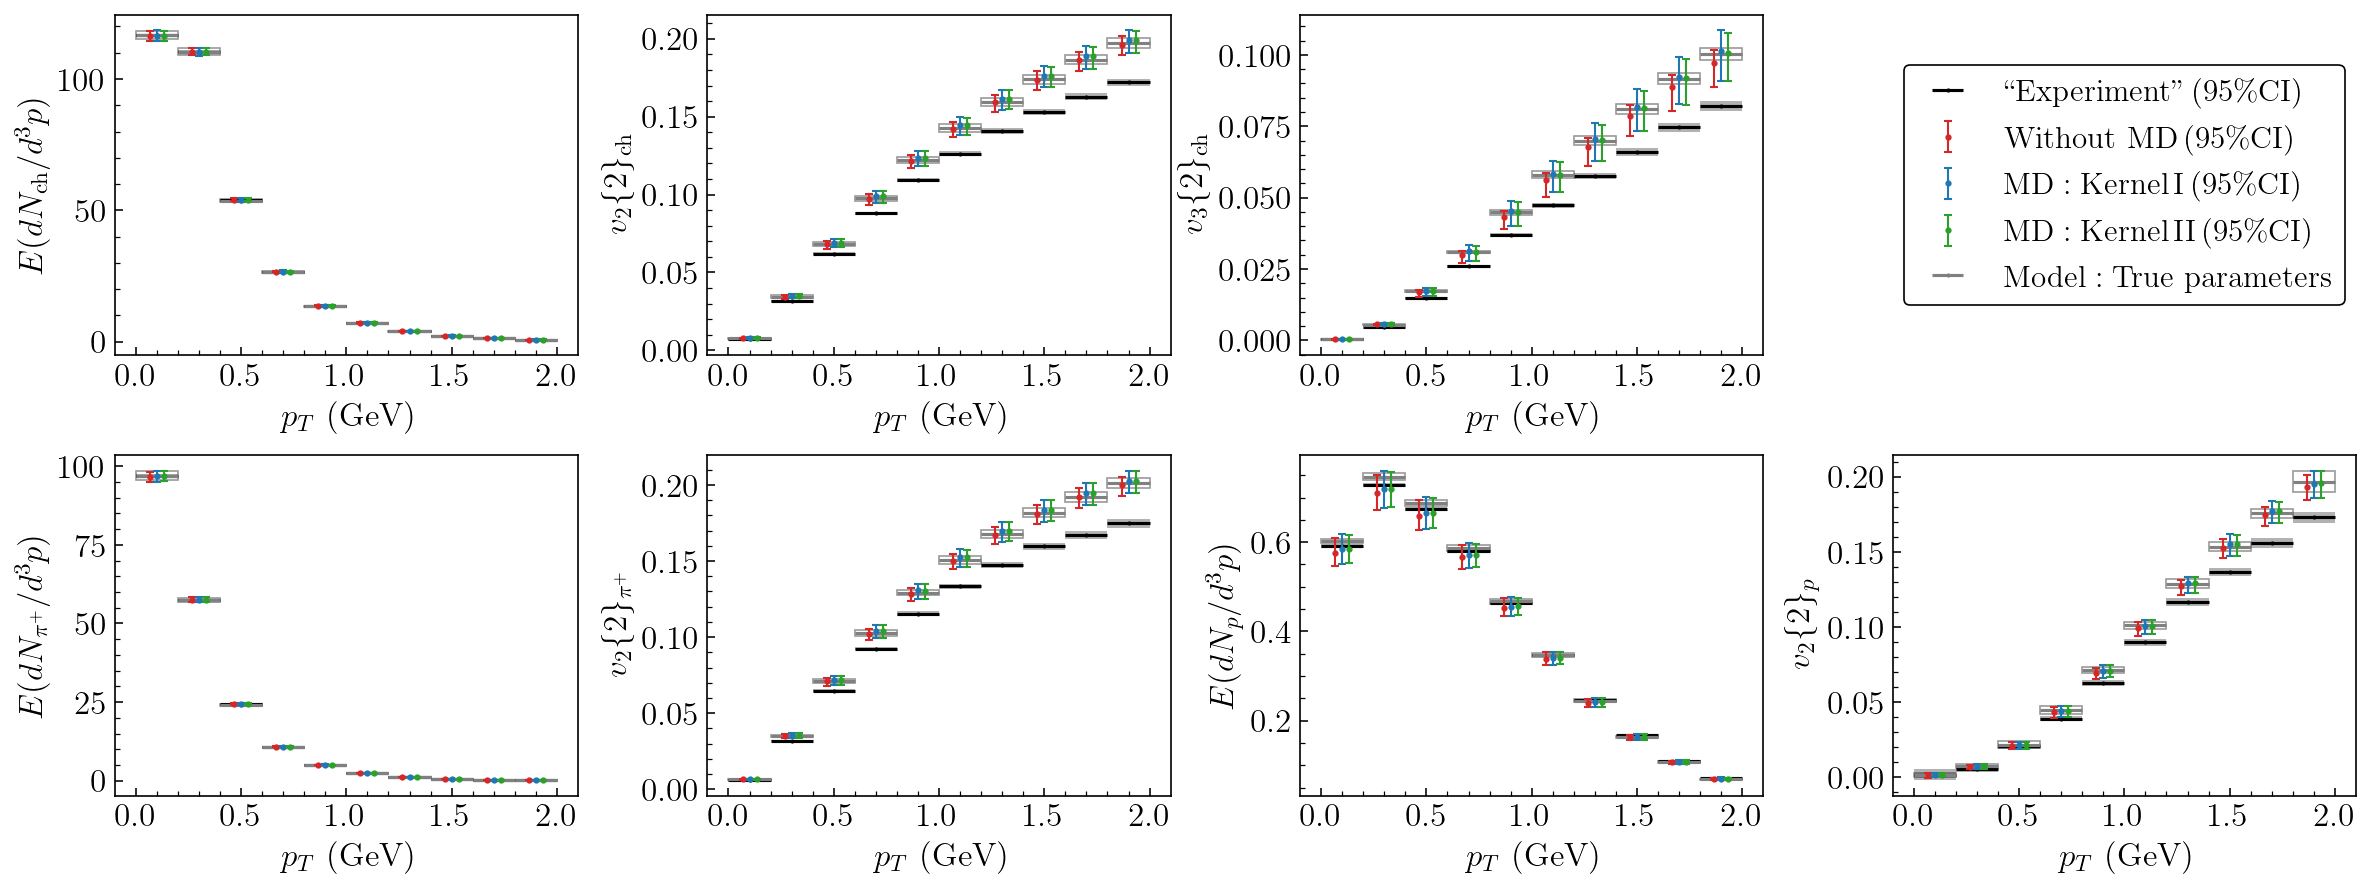

In [4]:
obs_name = "CH_dNdPT"   # calibration only with dN_{ch}/d^3p
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load quantiles
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_model(exp_data=experimental_data, 
               emu=emu,
               quantiles1=quantiles_wo_MD, 
               quantiles2=quantiles_w_MD_kernel1, 
               quantiles3=quantiles_w_MD_kernel2, 
               true_param=true_param_emu,
               obs_labels=obs_labels,
               legends=legends,
               colors = colors
               # ,fig_name = f"{dir_path}/obs_{obs_name}.pdf"
              )

/Users/jaiswal/Desktop/ModelDiscrepancy-main/projects/arXiv_2504.13144/heavy-ion/plot_scripts_heavyion.py:139: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


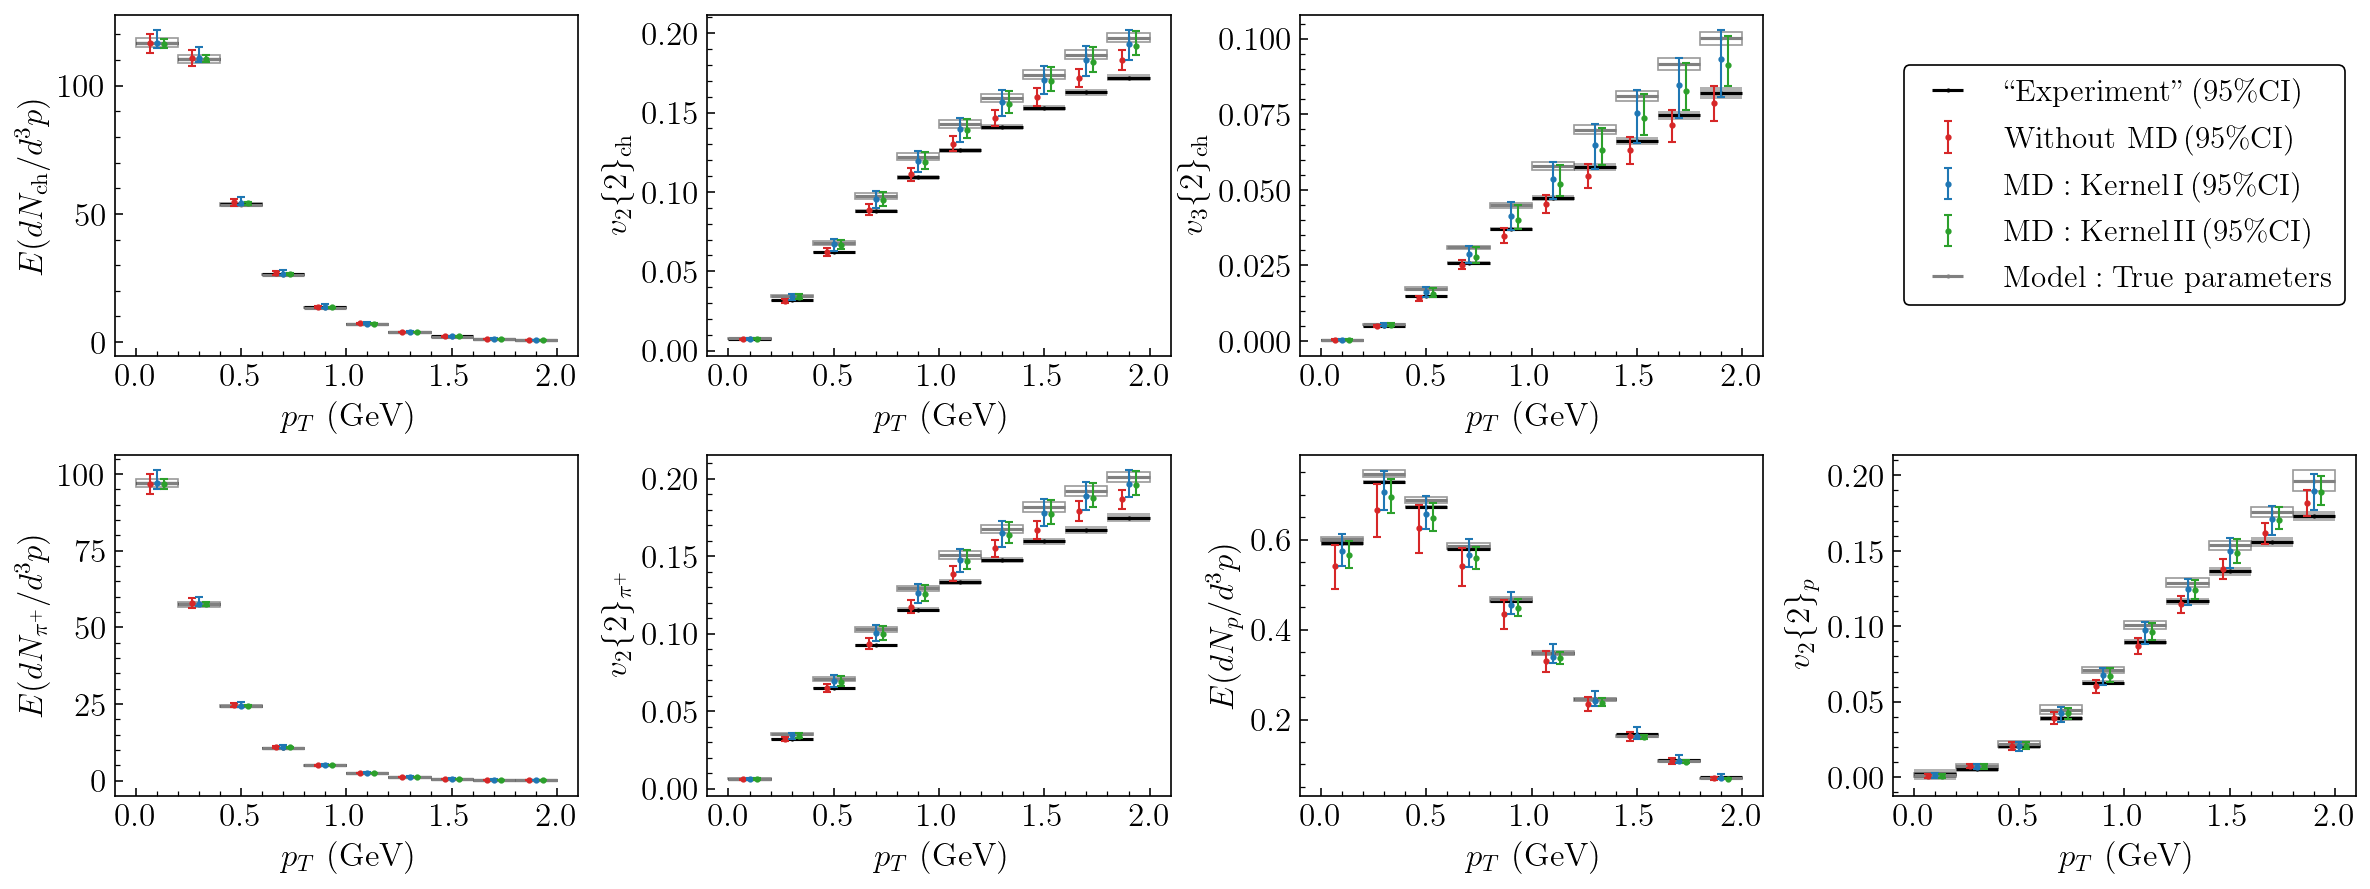

In [5]:
obs_name = "CH_dNdPT_v2_v3"   # calibration with dN_{ch}/d^3p, v_2^{ch}, v_3^{ch}
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load quantiles
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_model(exp_data=experimental_data, 
               emu=emu,
               quantiles1=quantiles_wo_MD, 
               quantiles2=quantiles_w_MD_kernel1, 
               quantiles3=quantiles_w_MD_kernel2, 
               true_param=true_param_emu,
               obs_labels=obs_labels,
               legends=legends,
               colors = colors
               # ,fig_name = f"{dir_path}/obs_{obs_name}.pdf"
              )

/Users/jaiswal/Desktop/ModelDiscrepancy-main/projects/arXiv_2504.13144/heavy-ion/plot_scripts_heavyion.py:139: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


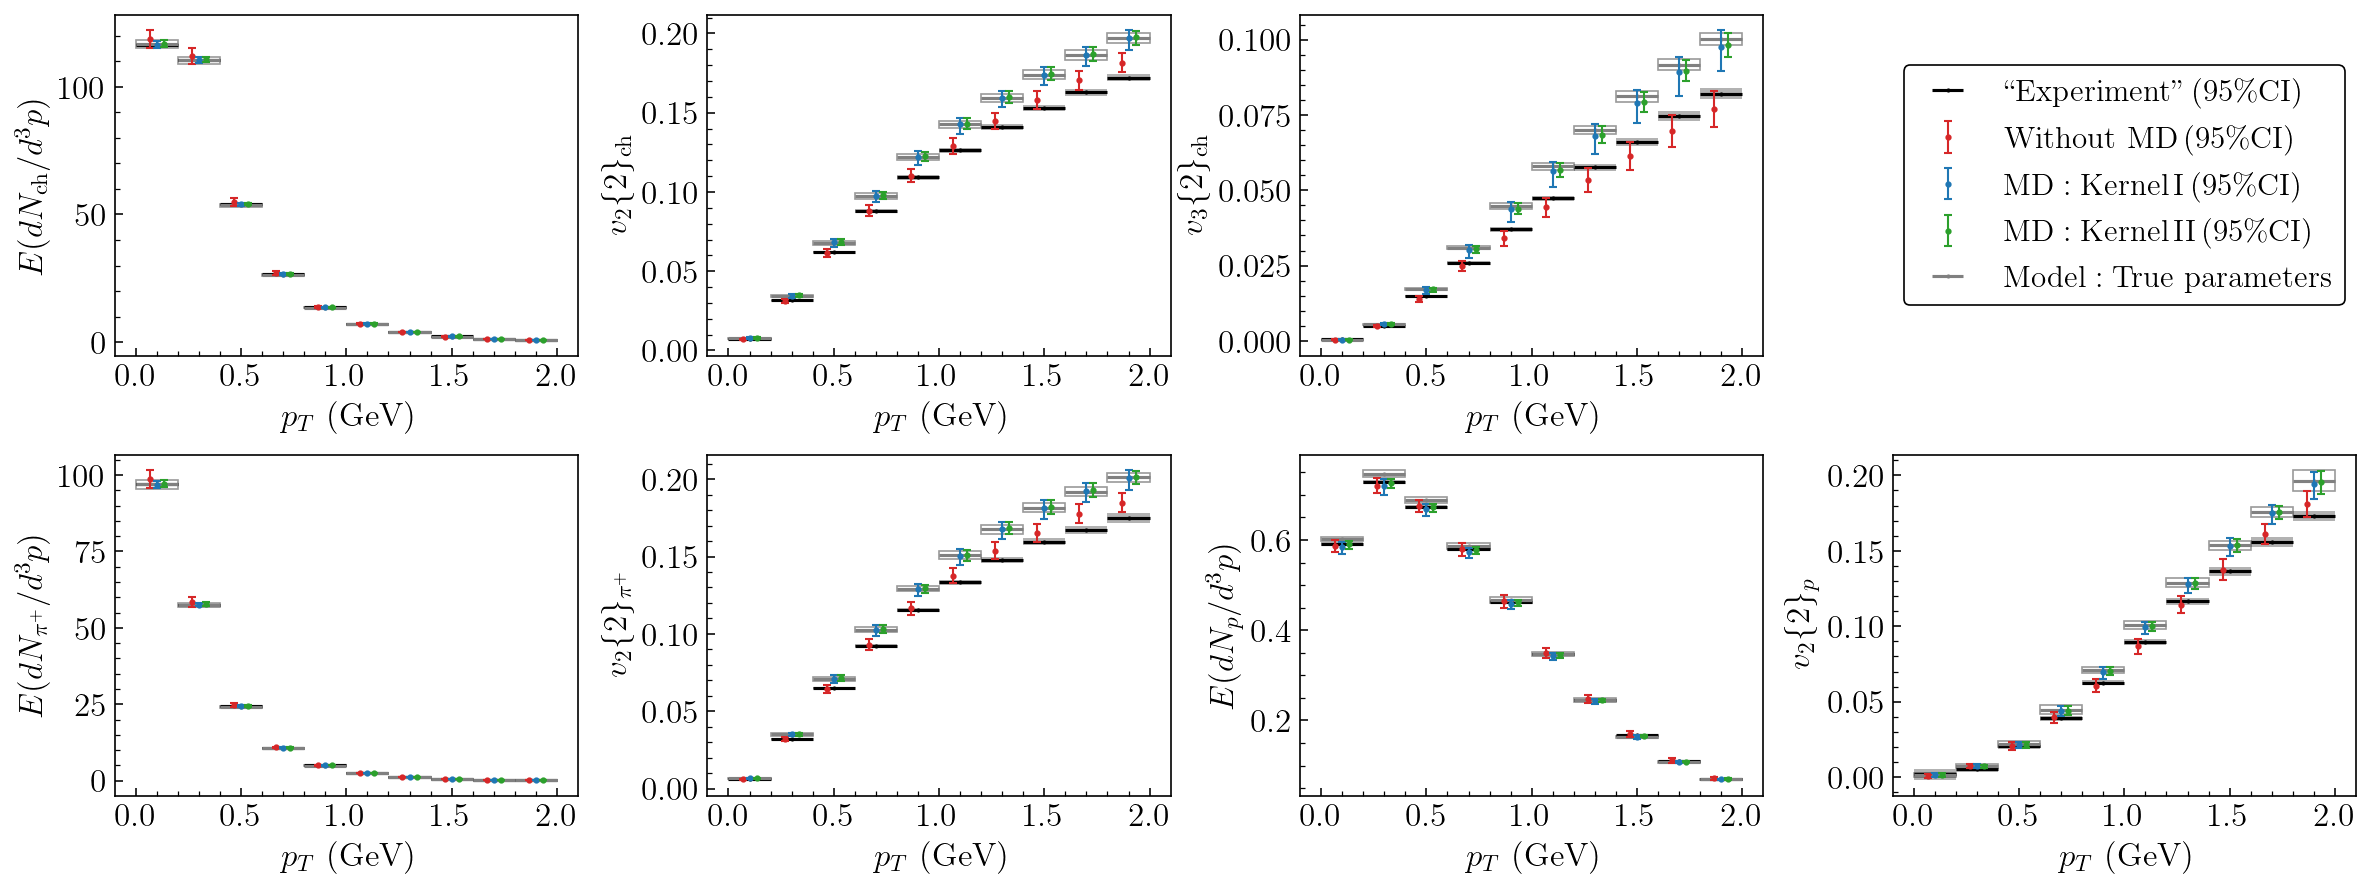

In [6]:
obs_name = "CH_pi+_p"   # calibration with all observables
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load quantiles
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_model(exp_data=experimental_data, 
               emu=emu,
               quantiles1=quantiles_wo_MD, 
               quantiles2=quantiles_w_MD_kernel1, 
               quantiles3=quantiles_w_MD_kernel2, 
               true_param=true_param_emu,
               obs_labels=obs_labels,
               legends=legends,
               colors = colors
               # ,fig_name = f"{dir_path}/obs_{obs_name}.pdf"
              )

## Plot Model + GP predictions

In [7]:
mod = 'modelPlusGP'

legends = [r'$\mathrm{``Experiment"\, (95\% CI)}$', 
           r"$\mathrm{Without \ MD\, (95\% CI)}$", 
           r"$\mathrm{Model+GP: Kernel\, I\, (95\% CI)}$", 
           r"$\mathrm{Model+GP: Kernel\, II\, (95\% CI)}$"]

obs_labels = [
    r'$E (dN_{\rm ch}/d^{3}p)$', r'$v_2\{2\}_{\rm ch}$', r'$v_3\{2\}_{\rm ch}$', r'$E (dN_{\pi^+}/d^{3}p)$', 
    r'$v_2\{2\}_{\pi^+}$', r'$E (dN_{p}/d^{3}p)$', r'$v_2\{2\}_{p}$'
]

/Users/jaiswal/Desktop/ModelDiscrepancy-main/projects/arXiv_2504.13144/heavy-ion/plot_scripts_heavyion.py:291: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


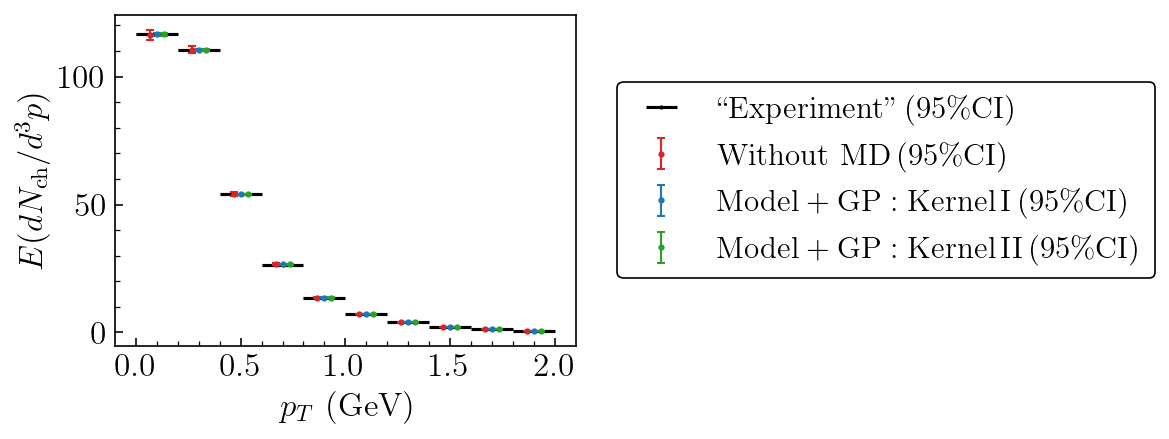

In [8]:
obs_name = 'CH_dNdPT'
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load quantiles
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_modelPlusGP(exp_data=experimental_data, 
                     emu=emu,
                     quantiles1=quantiles_wo_MD, 
                     quantiles2=quantiles_w_MD_kernel1, 
                     quantiles3=quantiles_w_MD_kernel2, 
                     true_param=true_param_emu,
                     obs_labels=obs_labels,
                     legends=legends,
                     colors = colors
                     # ,fig_name = f"{dir_path}/obs_{obs_name}.pdf"
                    )

/Users/jaiswal/Desktop/ModelDiscrepancy-main/projects/arXiv_2504.13144/heavy-ion/plot_scripts_heavyion.py:291: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


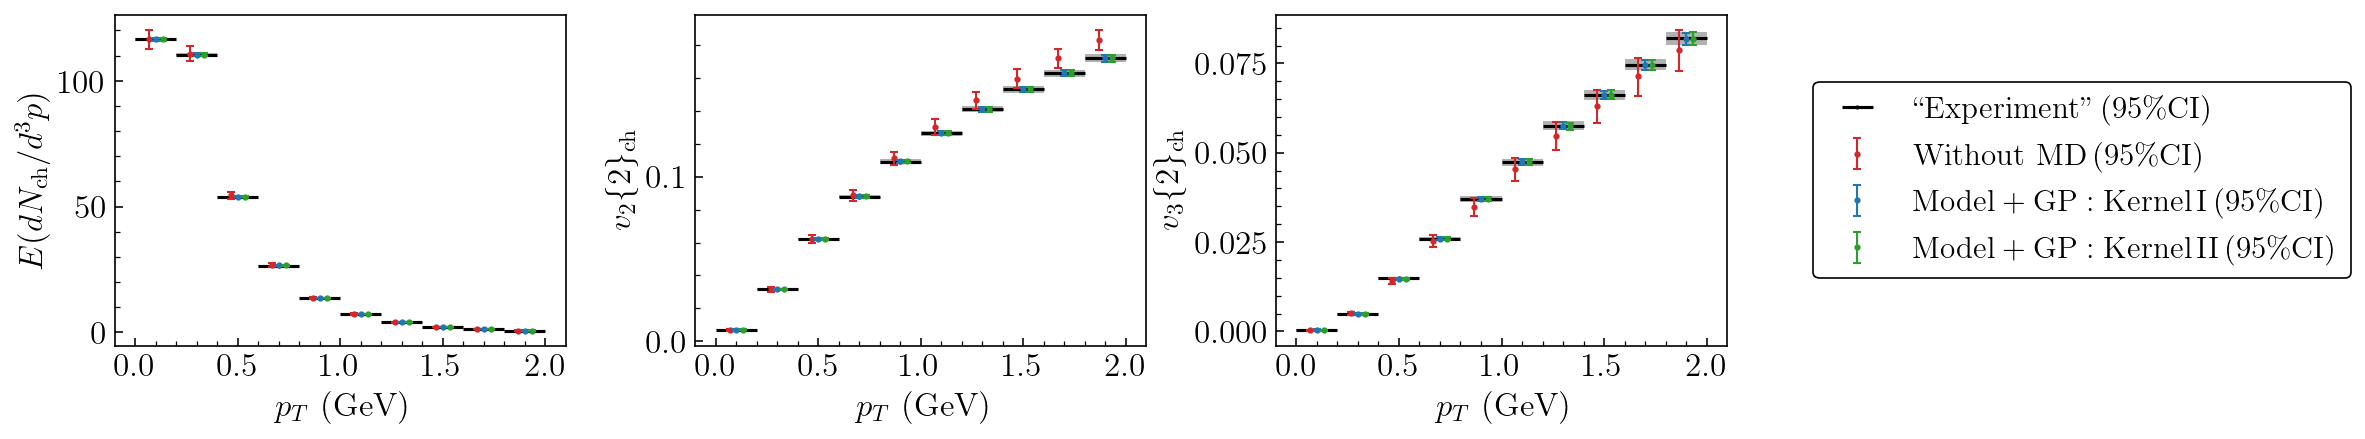

In [9]:
obs_name = 'CH_dNdPT_v2_v3'
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load quantiles
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_modelPlusGP(exp_data=experimental_data, 
                     emu=emu,
                     quantiles1=quantiles_wo_MD, 
                     quantiles2=quantiles_w_MD_kernel1, 
                     quantiles3=quantiles_w_MD_kernel2, 
                     true_param=true_param_emu,
                     obs_labels=obs_labels,
                     legends=legends,
                     colors = colors
                     # ,fig_name = f"{dir_path}/obs_{obs_name}.pdf"
                    )

/Users/jaiswal/Desktop/ModelDiscrepancy-main/projects/arXiv_2504.13144/heavy-ion/plot_scripts_heavyion.py:291: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


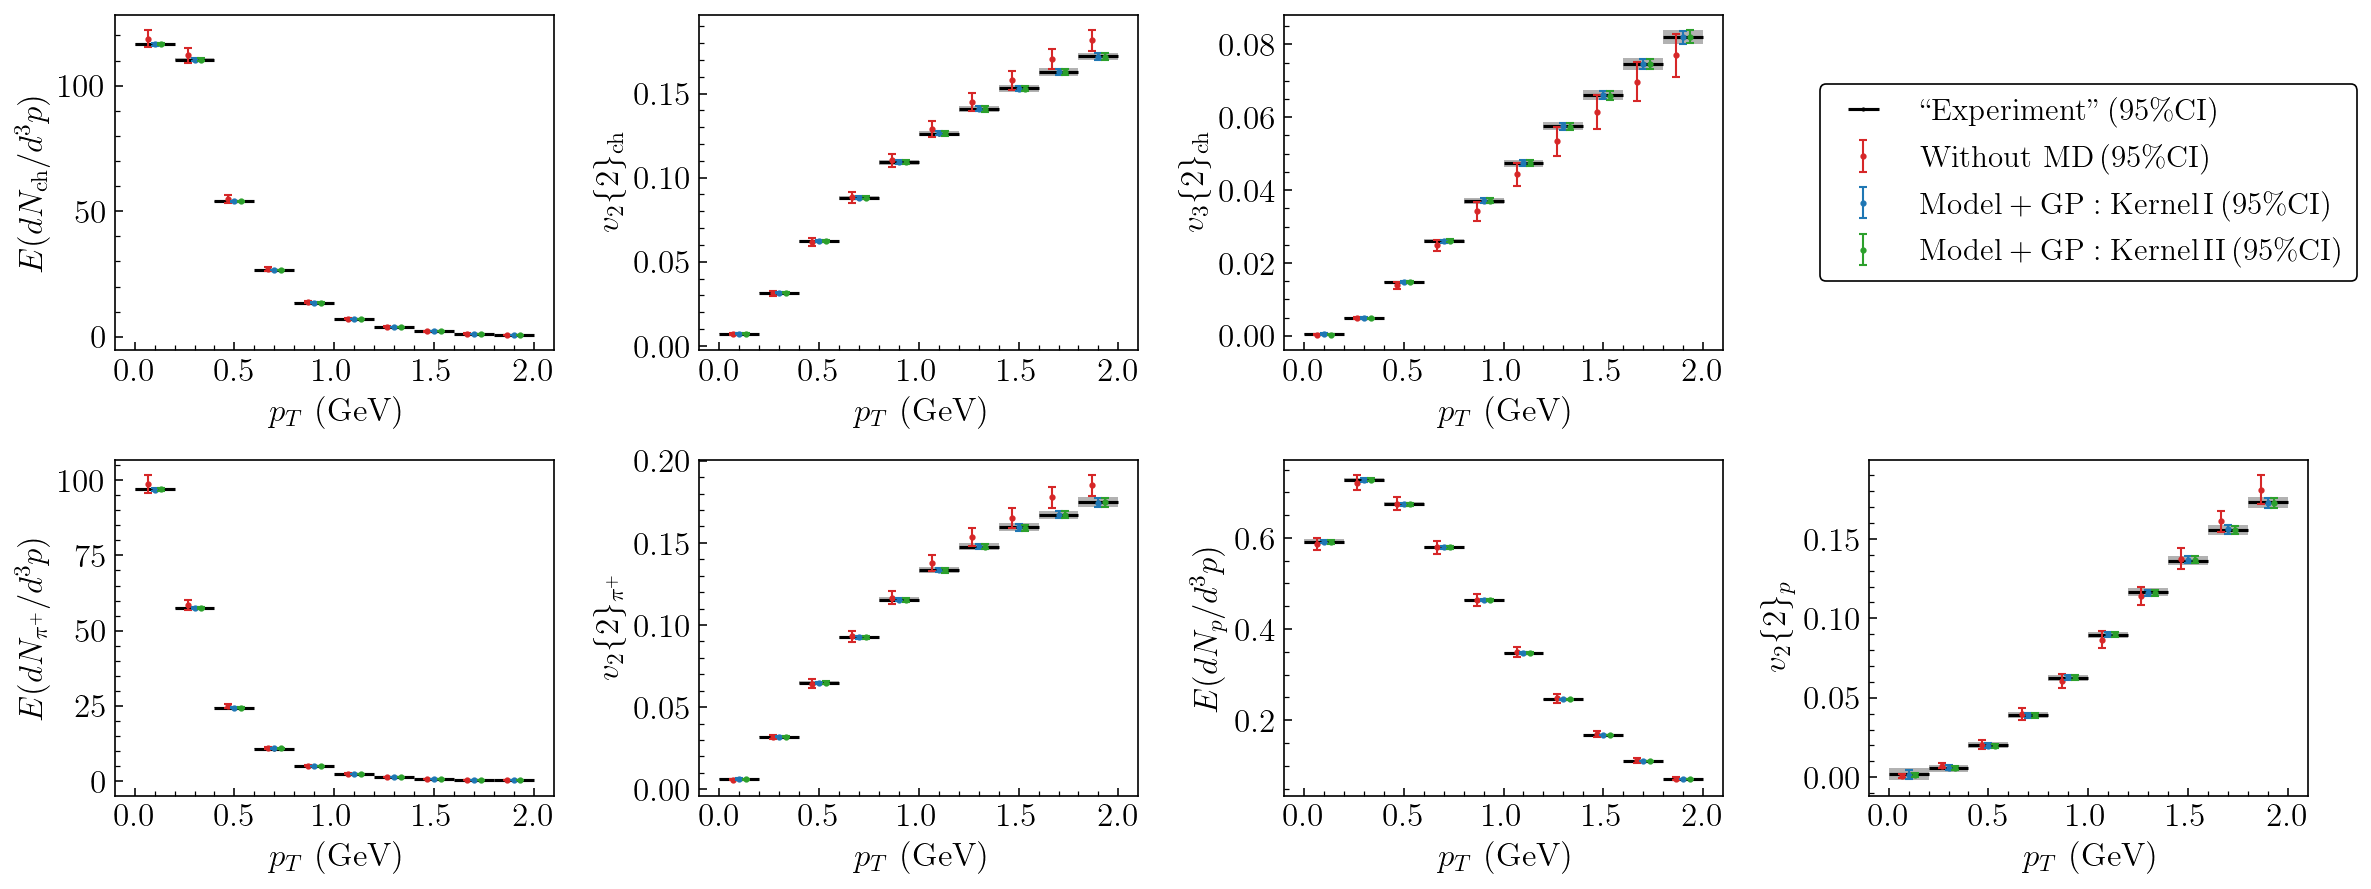

In [10]:
obs_name = 'CH_pi+_p'
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load quantiles
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_modelPlusGP(exp_data=experimental_data, 
                     emu=emu,
                     quantiles1=quantiles_wo_MD, 
                     quantiles2=quantiles_w_MD_kernel1, 
                     quantiles3=quantiles_w_MD_kernel2, 
                     true_param=true_param_emu,
                     obs_labels=obs_labels,
                     legends=legends,
                     colors = colors
                     # ,fig_name = f"{dir_path}/obs_{obs_name}.pdf"
                    )

## $\eta/s$ and corner plots

In [11]:
delta = model_param_bounds[:, 1] - model_param_bounds[:, 0]
# Extend the bounds by 5% on each side
extended_bounds = np.column_stack((
    model_param_bounds[:, 0] - 0.05 * delta,
    model_param_bounds[:, 1] + 0.05 * delta
))

labels = [r'$T_{\rm kink}$', r'$a_{\rm low}$',r'$a_{\rm high}$',r'$(\eta/s)_{\rm kink}$',r'$\epsilon_{\rm sw}$']

legends = [r"$\mathrm{Without \ MD}$", 
           r"$\mathrm{MD: Kernel\, I}$", 
           r"$\mathrm{MD: Kernel\, II}$"]

# Add a legend on the diagonal
legend_lines = [
    Line2D([0], [0], color=colors[0], linewidth=2, label=legends[0]),
    Line2D([0], [0], color=colors[1], linewidth=2, label=legends[1]),
    Line2D([0], [0], color=colors[2], linewidth=2, label=legends[2])
]



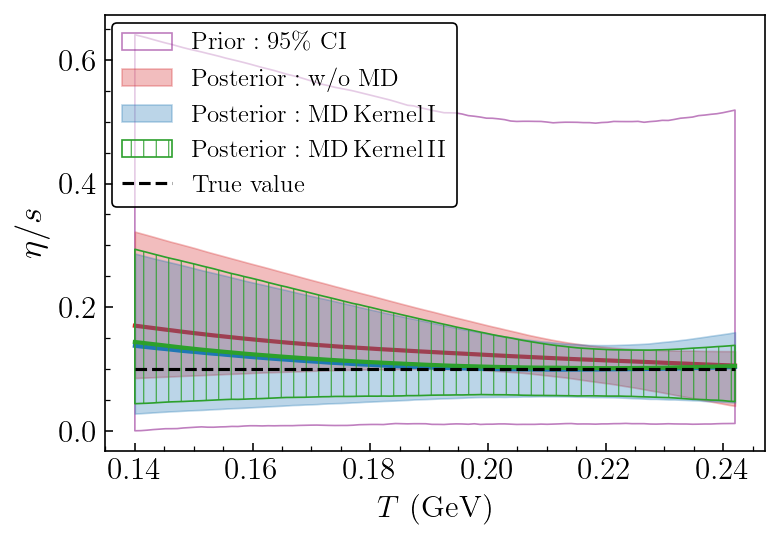

/Users/jaiswal/miniconda3/envs/md/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


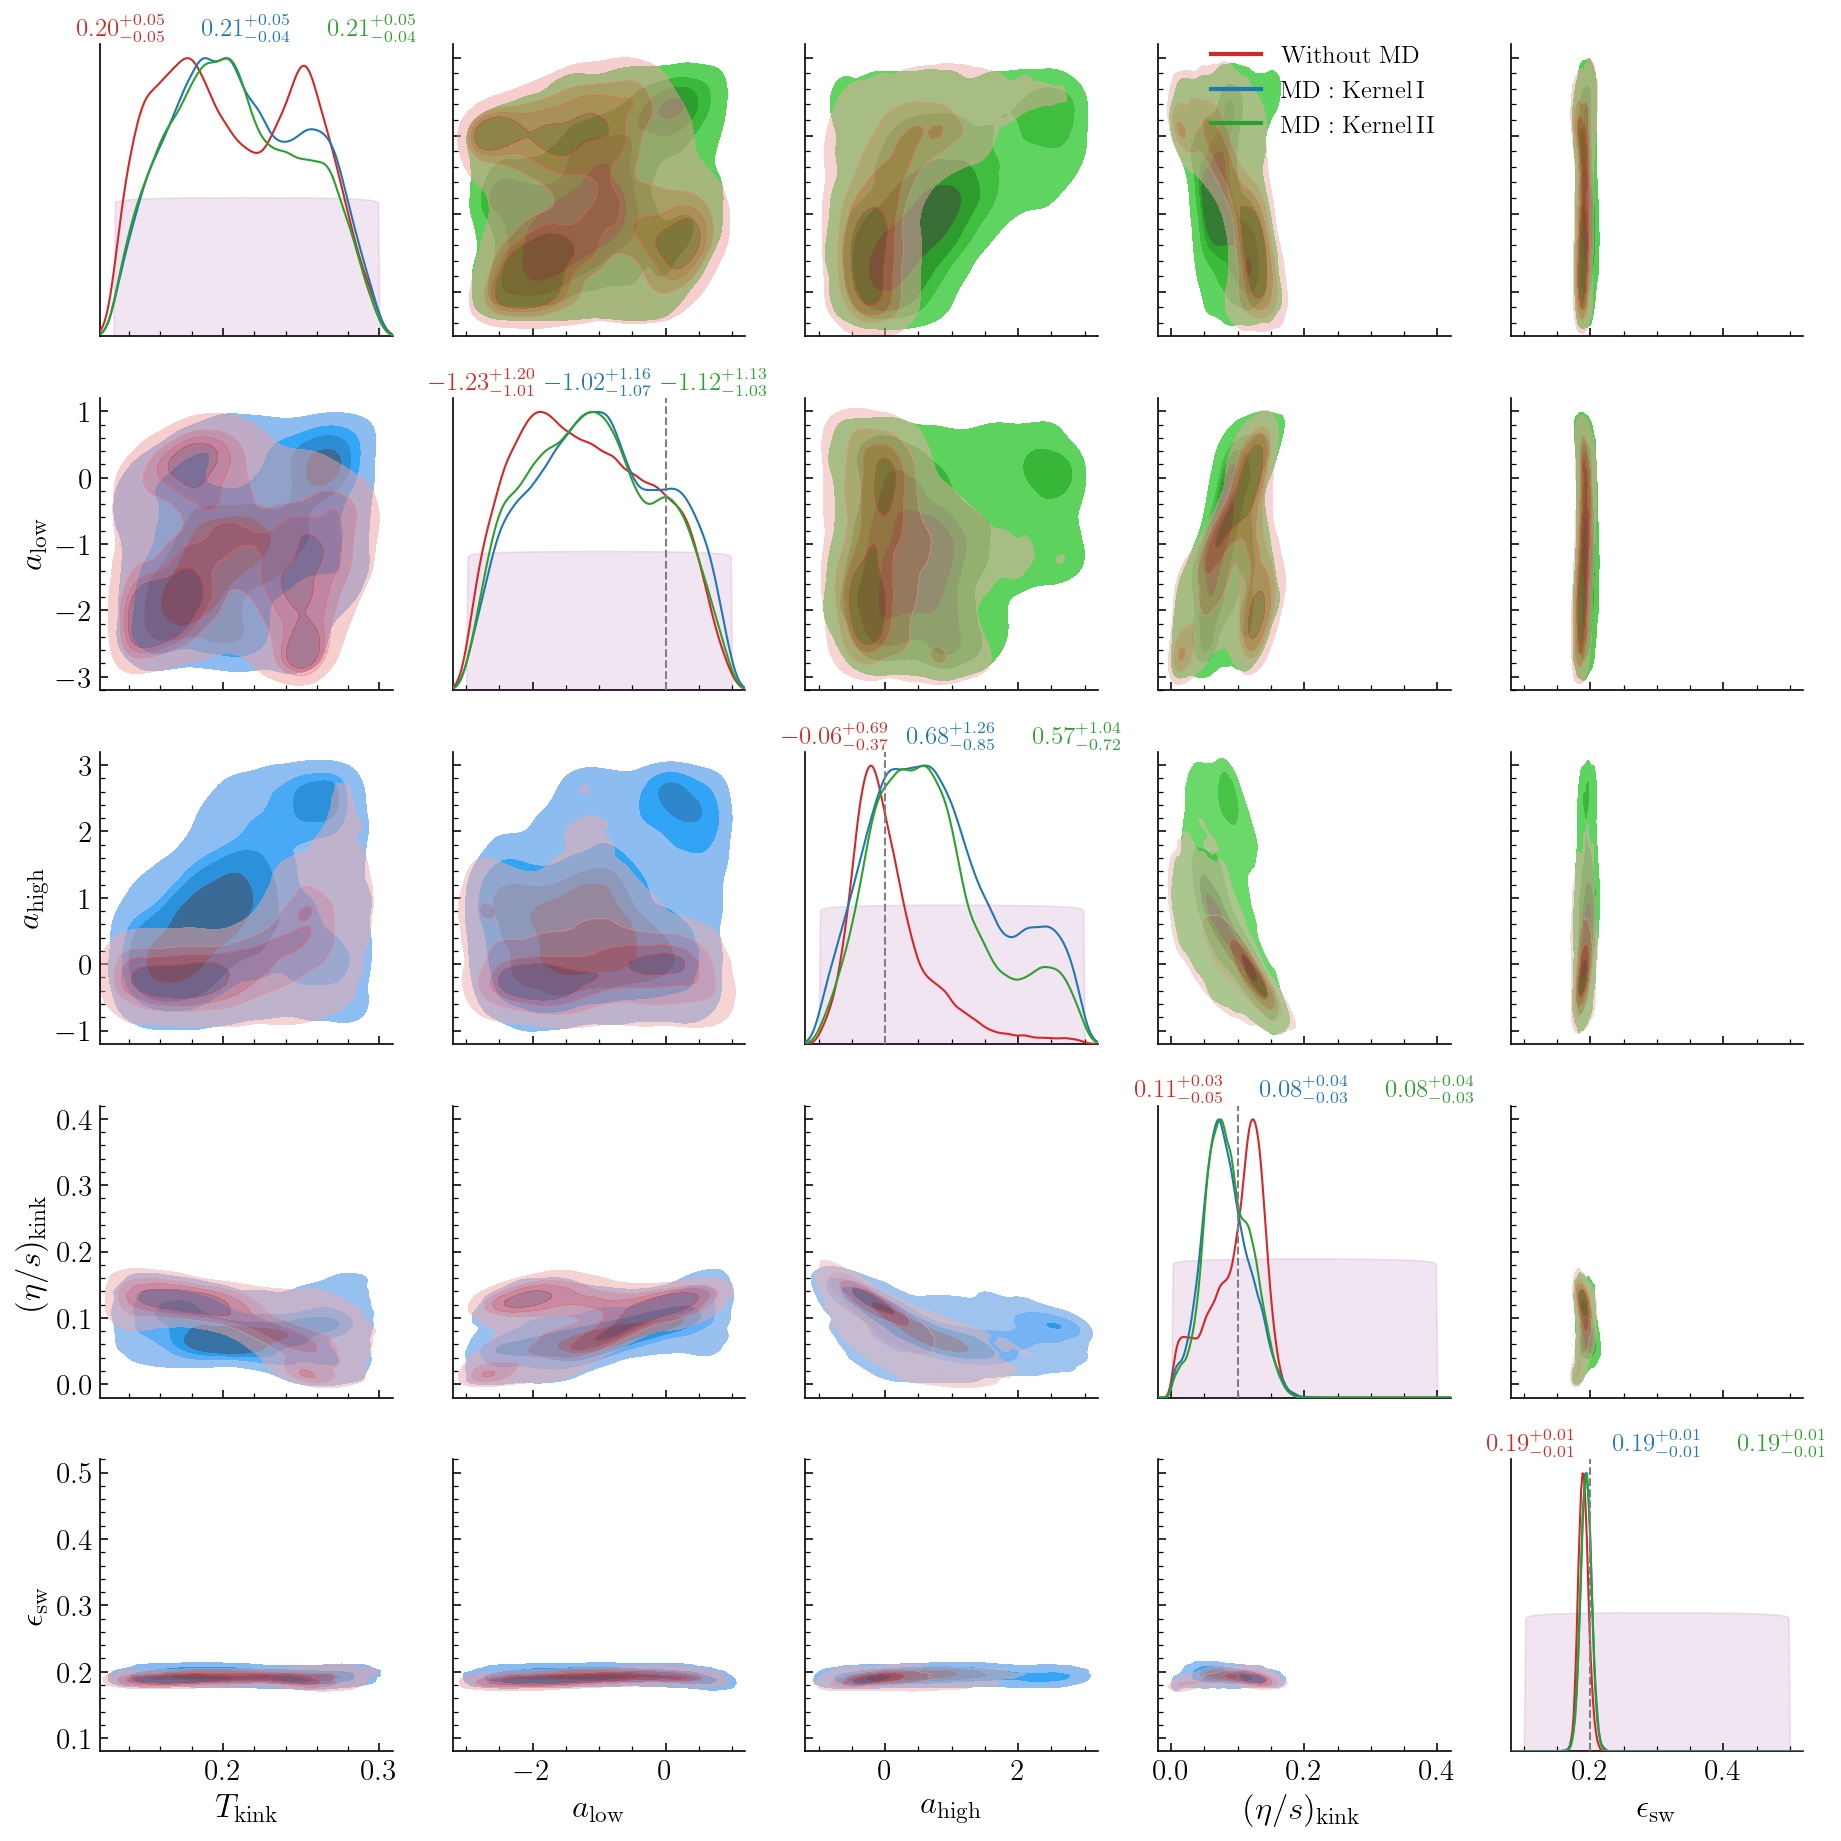

In [12]:
obs_name = "CH_dNdPT"
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load samples
samples_wo_MD = np.load(f'{dir_path}/wo_MD/pocomc_chain_{num_samples}.npy')
samples_w_MD_kernel1 = np.load(f'{dir_path}/w_MD_kernel1/pocomc_chain_{num_samples}.npy')
samples_w_MD_kernel2 = np.load(f'{dir_path}/w_MD_kernel2/pocomc_chain_{num_samples}.npy')

# slice to get samples of model parameters
samples1 = samples_wo_MD[:,:num_model_param]
samples2 = samples_w_MD_kernel1[:,:num_model_param]
samples3 = samples_w_MD_kernel2[:,:num_model_param]

# ------------------------------------

plot_etabys(samples1=samples1, samples2=samples2, samples3=samples3, 
            eta_over_s=eta_over_s,
            true_param=true_param_emu, model_param_bounds=model_param_bounds, colors=colors 
            # ,fig_name=f"{dir_path}/{ppname}_etabys_{obs_name}.pdf"
           )

# ------------------------------------

g = plt_corner3(samples_1=samples1, samples_2=samples2, samples_3=samples3, 
                    color = colors, 
                    plot_labels=labels, 
                    param_ranges = extended_bounds,
                    truth = true_param_corner,
                    priors = log_prior_theta)

gg = g.axes[0, 3] 
gg.legend(
    handles=legend_lines,
    loc='upper right',
    bbox_to_anchor=(1.05, 1.1),
    bbox_transform=gg.transAxes,
    fontsize=12,
    frameon=False
)
plt.tight_layout()
# g.savefig(f"{dir_path}/corner_{obs_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()

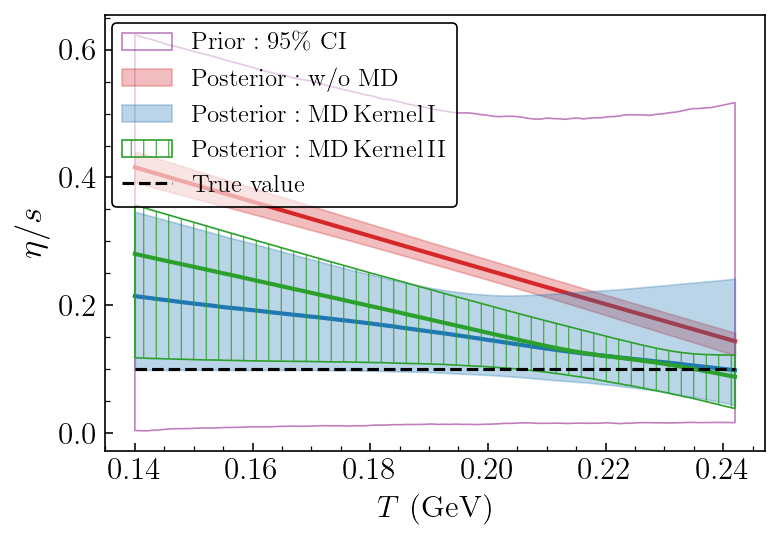

/Users/jaiswal/miniconda3/envs/md/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


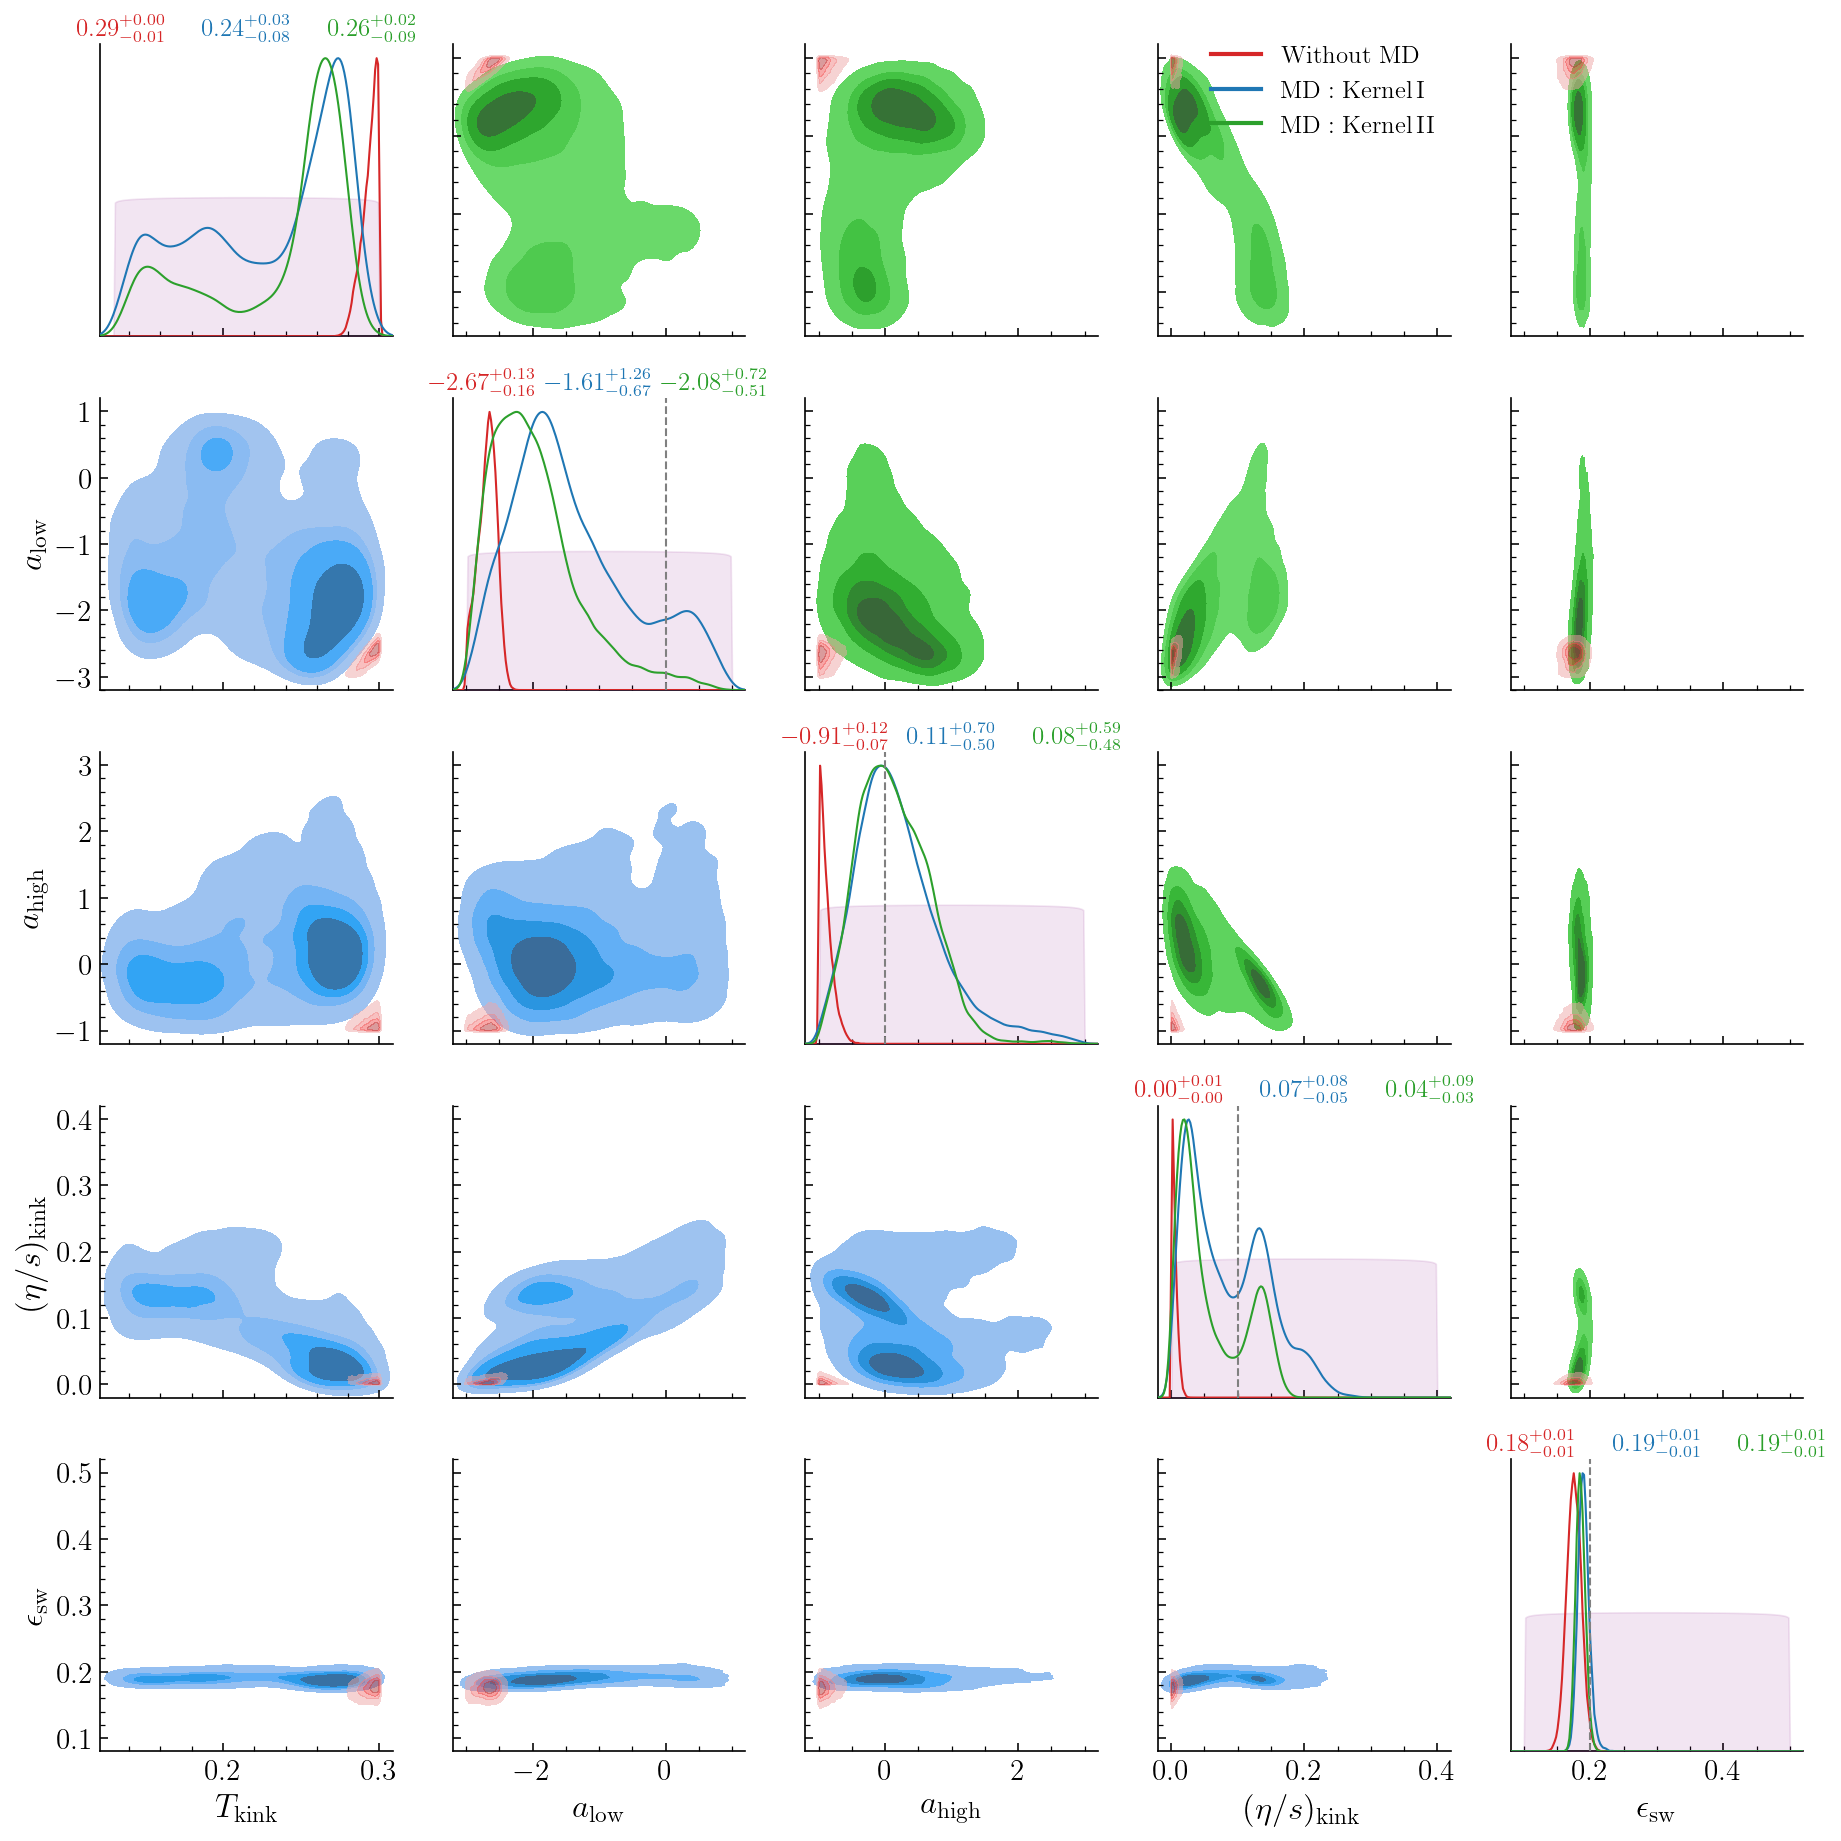

In [13]:
obs_name = "CH_dNdPT_v2_v3"
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load samples
samples_wo_MD = np.load(f'{dir_path}/wo_MD/pocomc_chain_{num_samples}.npy')
samples_w_MD_kernel1 = np.load(f'{dir_path}/w_MD_kernel1/pocomc_chain_{num_samples}.npy')
samples_w_MD_kernel2 = np.load(f'{dir_path}/w_MD_kernel2/pocomc_chain_{num_samples}.npy')

# slice to get samples of model parameters
samples1 = samples_wo_MD[:,:num_model_param]
samples2 = samples_w_MD_kernel1[:,:num_model_param]
samples3 = samples_w_MD_kernel2[:,:num_model_param]

# ------------------------------------

plot_etabys(samples1=samples1, samples2=samples2, samples3=samples3, 
            eta_over_s=eta_over_s,
            true_param=true_param_emu, model_param_bounds=model_param_bounds, colors=colors 
            # ,fig_name=f"{dir_path}/{ppname}_etabys_{obs_name}.pdf"
           )

# ------------------------------------

g = plt_corner3(samples_1=samples1, samples_2=samples2, samples_3=samples3, 
                    color = colors, 
                    plot_labels=labels, 
                    param_ranges = extended_bounds,
                    truth = true_param_corner,
                    priors = log_prior_theta)

gg = g.axes[0, 3] 
gg.legend(
    handles=legend_lines,
    loc='upper right',
    bbox_to_anchor=(1.05, 1.1),
    bbox_transform=gg.transAxes,
    fontsize=12,
    frameon=False
)
plt.tight_layout()
# g.savefig(f"{dir_path}/corner_{obs_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()

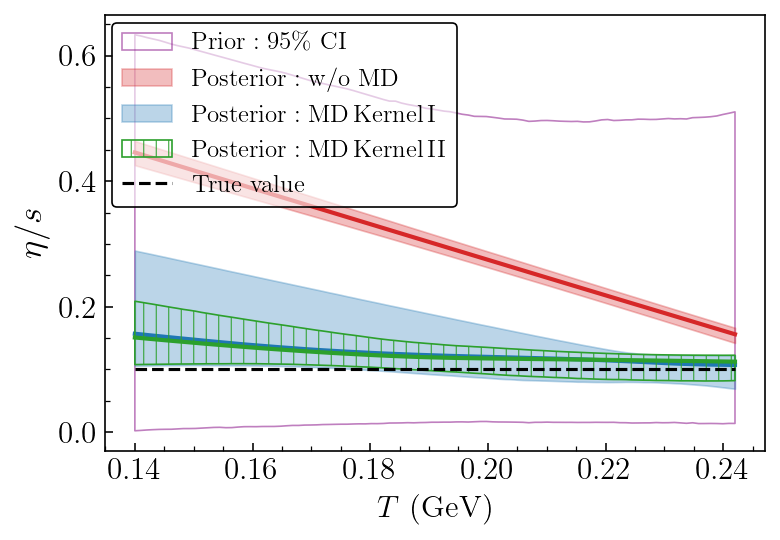

/Users/jaiswal/miniconda3/envs/md/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


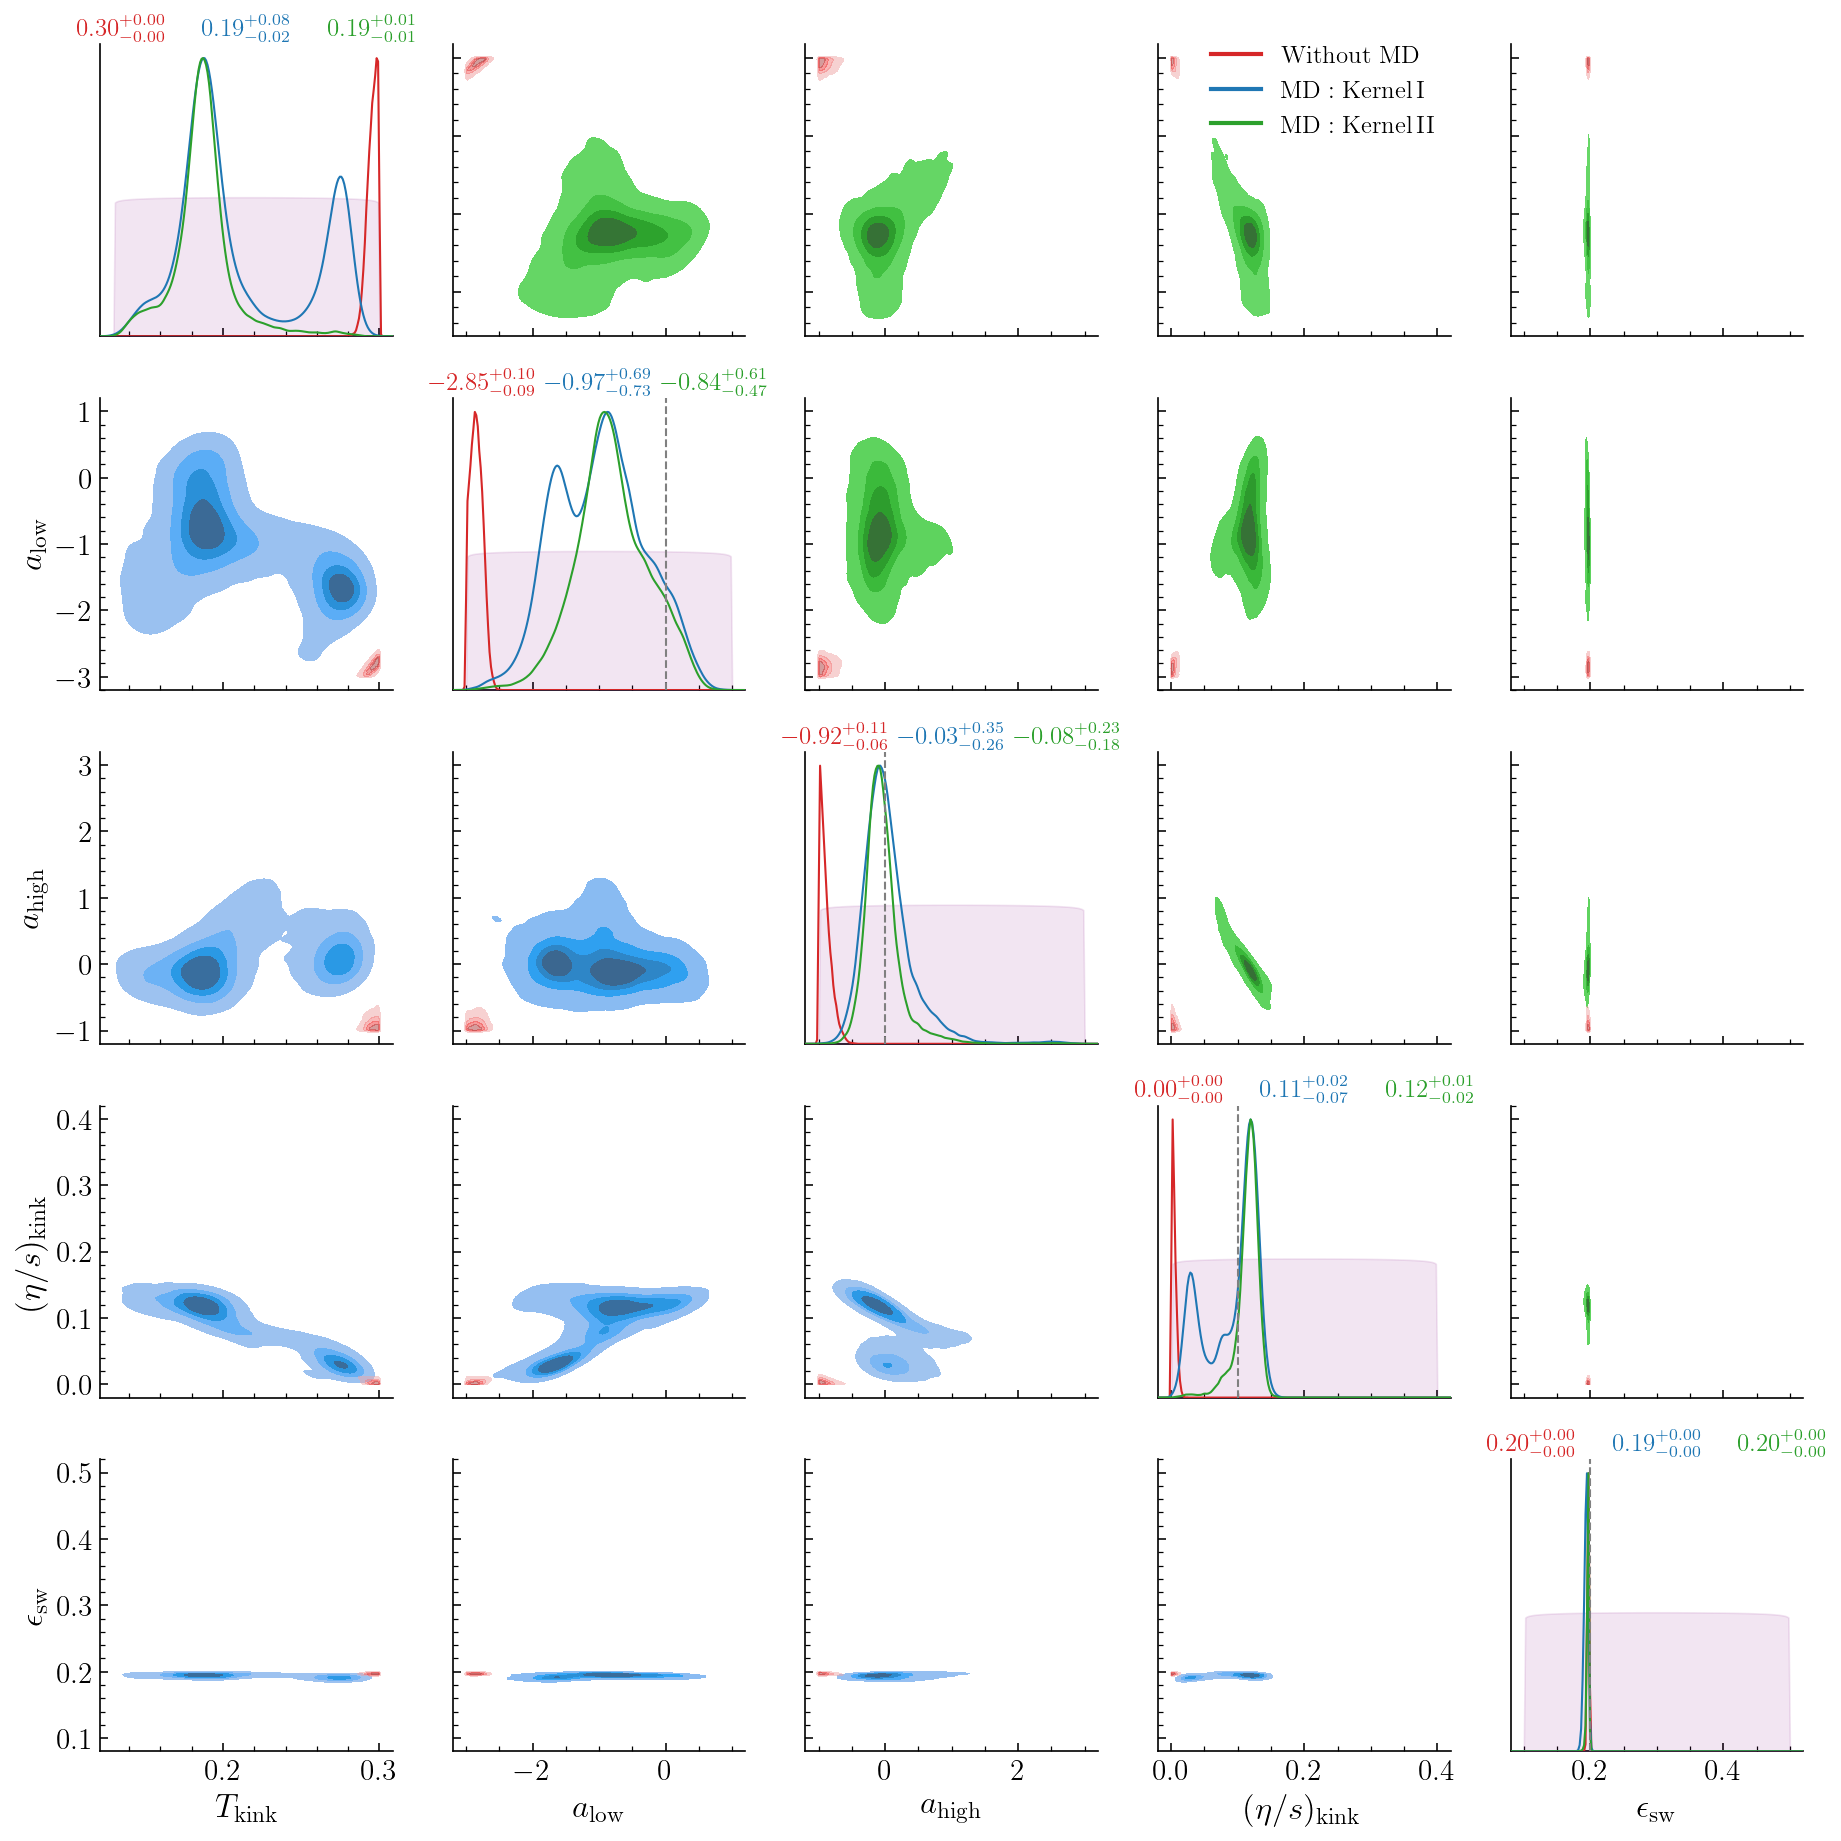

In [14]:
obs_name = "CH_pi+_p"
dir_path = f"mcmc_data/{exp}/obs_{obs_name}"

# load samples
samples_wo_MD = np.load(f'{dir_path}/wo_MD/pocomc_chain_{num_samples}.npy')
samples_w_MD_kernel1 = np.load(f'{dir_path}/w_MD_kernel1/pocomc_chain_{num_samples}.npy')
samples_w_MD_kernel2 = np.load(f'{dir_path}/w_MD_kernel2/pocomc_chain_{num_samples}.npy')

# slice to get samples of model parameters
samples1 = samples_wo_MD[:,:num_model_param]
samples2 = samples_w_MD_kernel1[:,:num_model_param]
samples3 = samples_w_MD_kernel2[:,:num_model_param]

# ------------------------------------

plot_etabys(samples1=samples1, samples2=samples2, samples3=samples3, 
            eta_over_s=eta_over_s,
            true_param=true_param_emu, model_param_bounds=model_param_bounds, colors=colors 
            # ,fig_name=f"{dir_path}/{ppname}_etabys_{obs_name}.pdf"
           )

# ------------------------------------

g = plt_corner3(samples_1=samples1, samples_2=samples2, samples_3=samples3, 
                    color = colors, 
                    plot_labels=labels, 
                    param_ranges = extended_bounds,
                    truth = true_param_corner,
                    priors = log_prior_theta)

gg = g.axes[0, 3] 
gg.legend(
    handles=legend_lines,
    loc='upper right',
    bbox_to_anchor=(1.05, 1.1),
    bbox_transform=gg.transAxes,
    fontsize=12,
    frameon=False
)
plt.tight_layout()
# g.savefig(f"{dir_path}/corner_{obs_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()